# 04 — Dataset, EDA, and Feature Engineering

Goal: inspect California Housing data and prepare clean inputs for model benchmark.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'pipeline').exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / 'pipeline').exists():
            PROJECT_ROOT = parent
            break
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)

Project root: /home/ahmad/AI/Github/40 AI-ML Projects for Beginners/MLOps, UI, and Deployment/Deploy a Machine Learning Model with Docker


## 4.1 Data Understanding
**Definition:** EDA identifies feature ranges, skew, correlation, and anomalies before modeling.

**Theory:** Explain mechanism, assumptions, and where this fits in deployment lifecycle.

**Motivation:** Why this matters for reliability, reproducibility, and operations.

**Real-World Example:** Population-heavy skew can bias model behavior if ignored.

**Visual Explanation:** See figure/code cell below.

**Code Explanation:** Code cell demonstrates concrete implementation details.

**Best Practices:** Always inspect distribution and split strategy before training.

**Common Mistakes:** Training models before validating feature quality and target behavior.

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Shape: (20640, 9)

Nulls: 0


Saved: outputs/figures/correlation-matrix.png


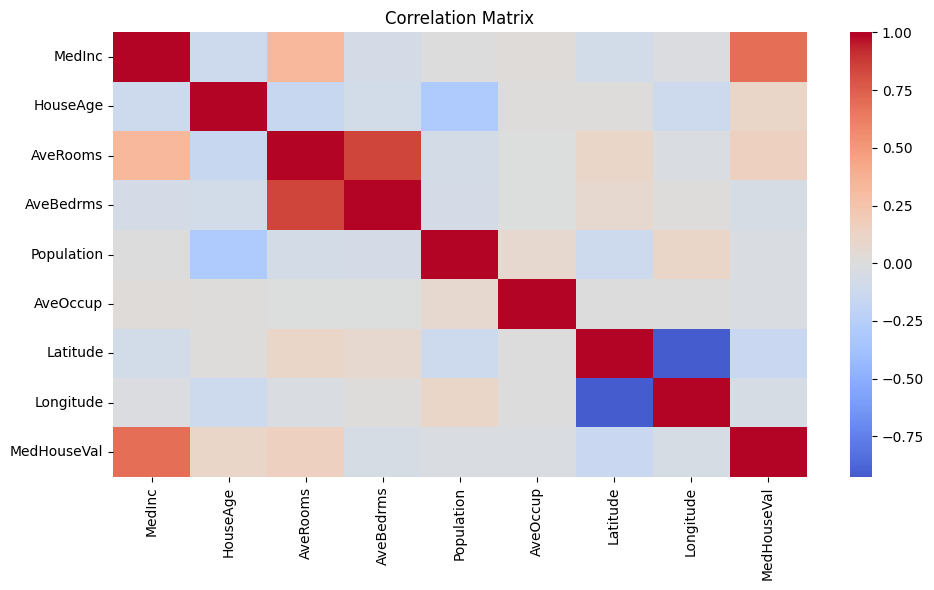

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing

out = Path('outputs/figures')
out.mkdir(parents=True, exist_ok=True)

frame = fetch_california_housing(as_frame=True).frame
print(frame.head())
print('\nShape:', frame.shape)
print('\nNulls:', frame.isna().sum().sum())

plt.figure(figsize=(10, 6))
cor = frame.corr(numeric_only=True)
sns.heatmap(cor, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(out / 'correlation-matrix.png', dpi=150)
print('Saved:', out / 'correlation-matrix.png')

## 4.2 Feature Engineering Strategy
**Definition:** Feature engineering transforms raw signals into model-relevant predictors while avoiding leakage.

**Theory:** Explain mechanism, assumptions, and where this fits in deployment lifecycle.

**Motivation:** Why this matters for reliability, reproducibility, and operations.

**Real-World Example:** Room density or occupancy transformations can improve nonlinear model fit.

**Visual Explanation:** See figure/code cell below.

**Code Explanation:** Code cell demonstrates concrete implementation details.

**Best Practices:** Fit preprocessing only on train split and apply identical transform to validation/test.

**Common Mistakes:** Computing transforms on full dataset before split, causing leakage.

In [3]:
from sklearn.model_selection import train_test_split

features = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']
X = frame[features]
y = frame['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Target mean train/test:', round(y_train.mean(), 3), round(y_test.mean(), 3))

Train: (16512, 8) Test: (4128, 8)
Target mean train/test: 2.072 2.055
